# Bahraini Currency Classification Using CNN
## Functional API

In [1]:
!pip install -q pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 55.6 MB/s eta 0:00:00


## 1. Setup

In [2]:
import os
import shutil
import zipfile
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image
from pillow_heif import register_heif_opener

from tensorflow.keras.utils import set_random_seed
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input,Rescaling,RandomFlip,RandomRotation,RandomZoom,RandomBrightness,Conv2D,BatchNormalization,Activation,MaxPooling2D,GlobalAveragePooling2D,Dense,Dropout)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

from sklearn.utils import compute_class_weight

## 2. Set Random Seed

In [3]:
seed = 100

random.seed(seed)
np.random.seed(seed)
set_random_seed(seed)

## 3. Extract ZIP

In [48]:
ZIP_FILE = "/content/Money.zip"
EXTRACT_FOLDER ="/content/Money"

if os.path.exists(EXTRACT_FOLDER):
    shutil.rmtree(EXTRACT_FOLDER)

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_FOLDER)

print("ZIP file extracted successfully.")

ZIP file extracted successfully.


## 4. Check Folders

In [49]:
for root, dirs, files in os.walk("/content/Money"):
    print(root)

/content/Money
/content/Money/__MACOSX
/content/Money/__MACOSX/Money
/content/Money/__MACOSX/Money/20BD
/content/Money/__MACOSX/Money/5BD
/content/Money/__MACOSX/Money/10BD
/content/Money/__MACOSX/Money/500 Fils
/content/Money/__MACOSX/Money/1BD
/content/Money/Money
/content/Money/Money/20BD
/content/Money/Money/5BD
/content/Money/Money/10BD
/content/Money/Money/500 Fils
/content/Money/Money/1BD


## 5. Define Paths & Classes

In [51]:
SOURCE_DIR = "/content/Money/Money"
DATA_DIR = "/content/currency_data"

currency_classes = ["500 Fils","1BD","5BD","10BD","20BD"]

print("Currency classes:", currency_classes)

Currency classes: ['500 Fils', '1BD', '5BD', '10BD', '20BD']


## 6. Convert Images to PNG

In [52]:
register_heif_opener()

if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)

os.makedirs(DATA_DIR, exist_ok=True)

for class_name in currency_classes:

    source_folder = os.path.join(SOURCE_DIR,class_name)

    output_folder = os.path.join(DATA_DIR,class_name)

    os.makedirs(output_folder,exist_ok=True)

    image_number = 1

    for file_name in os.listdir(source_folder):

        file_path = os.path.join(source_folder,file_name)

        if not os.path.isfile(file_path):
            continue

        try:
            image = Image.open(file_path).convert("RGB")

            output_path = os.path.join(output_folder,f"{class_name}_{image_number}.png")

            image.save(output_path)

            image_number += 1

        except Exception as error:
            print("Skipped:",file_name,error)

print("Image conversion completed.")

Skipped: .DS_Store cannot identify image file '/content/Money/Money/500 Fils/.DS_Store'
Skipped: .DS_Store cannot identify image file '/content/Money/Money/1BD/.DS_Store'
Skipped: .DS_Store cannot identify image file '/content/Money/Money/5BD/.DS_Store'
Skipped: .DS_Store cannot identify image file '/content/Money/Money/10BD/.DS_Store'
Skipped: .DS_Store cannot identify image file '/content/Money/Money/20BD/.DS_Store'
Image conversion completed.


## 7. Count Images per Class

In [53]:
image_counts = {}

for class_name in currency_classes:

    folder_path = os.path.join(DATA_DIR,class_name)

    number_of_images = len([file_name
        for file_name in os.listdir(folder_path)
        if file_name.lower().endswith((".png", ".jpg", ".jpeg"))])

    image_counts[class_name] = number_of_images

    print(class_name,":",number_of_images,"images")

500 Fils : 222 images
1BD : 201 images
5BD : 222 images
10BD : 226 images
20BD : 226 images


## 8. Visualize Class Distribution

In [54]:
counts_df = pd.DataFrame({"Class": image_counts.keys(),"Number of Images": image_counts.values()})

counts_df

,Class,Number of Images
0,500 Fils,222
1,1BD,201
2,5BD,222
3,10BD,226
4,20BD,226


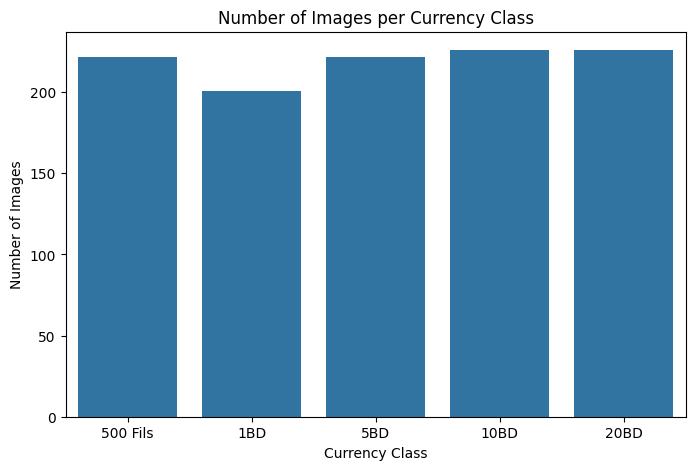

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(data=counts_df,x="Class",y="Number of Images")

plt.title("Number of Images per Currency Class")
plt.xlabel("Currency Class")
plt.ylabel("Number of Images")
plt.show()

## 9. Load Dataset (Train/Validation Split)

In [56]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [57]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 1097 files belonging to 5 classes.
Using 878 files for training.


In [58]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1097 files belonging to 5 classes.
Using 219 files for validation.


## 10. Explore Data & Define Augmentation

In [59]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['10BD', '1BD', '20BD', '500 Fils', '5BD']
Number of classes: 5


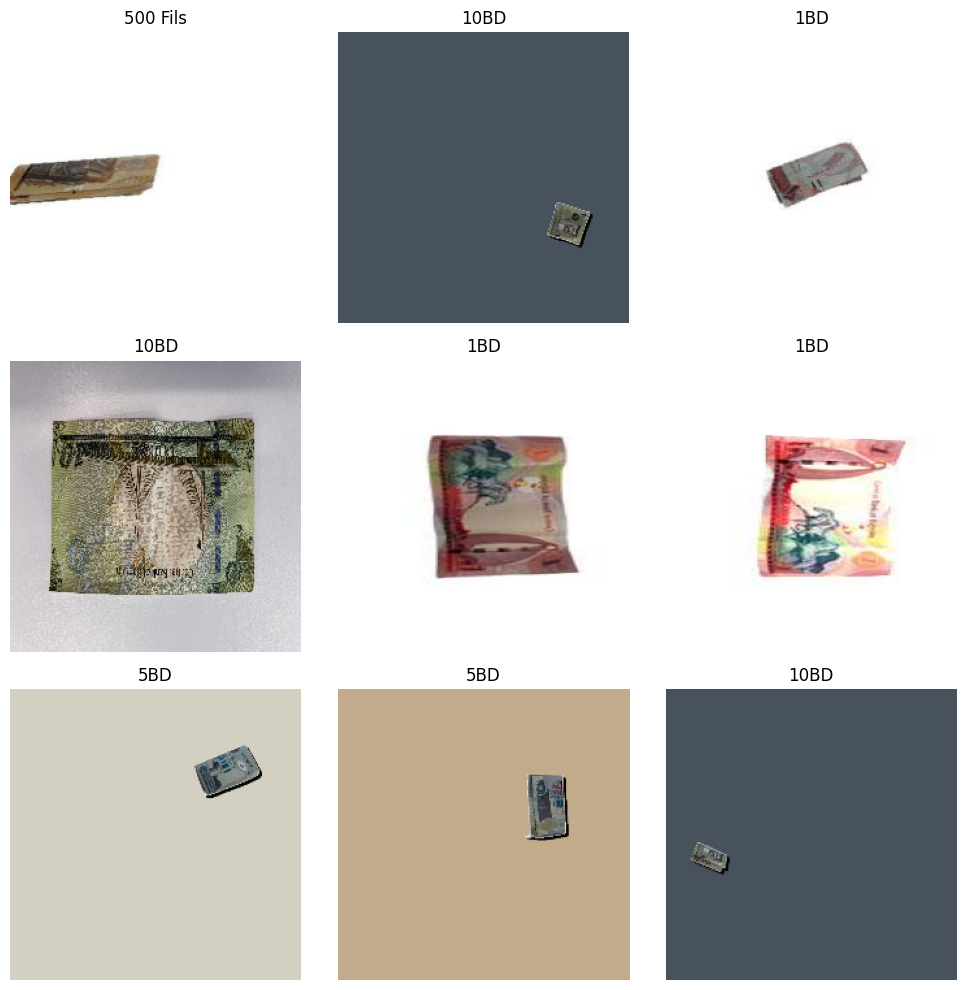

In [60]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    number_of_images = min(9,images.shape[0])

    for i in range(number_of_images):

        plt.subplot(3,3,i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label_number = int(labels[i].numpy())

        plt.title(class_names[label_number])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [61]:
train_labels = np.array([int(label.numpy())for _, label in train_ds.unbatch()])

train_counts = pd.Series(train_labels).value_counts().sort_index()

train_counts.index = [class_names[index]for index in train_counts.index]

train_counts

,count
10BD,179
1BD,164
20BD,182
500 Fils,166
5BD,187


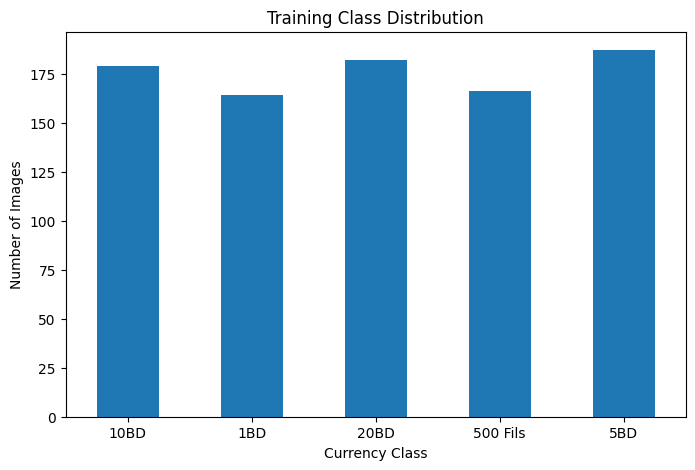

In [62]:
train_counts.plot(kind="bar",figsize=(8, 5))

plt.title("Training Class Distribution")
plt.xlabel("Currency Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

In [63]:
data_augmentation = tf.keras.Sequential([RandomFlip("horizontal"),RandomRotation(0.1),RandomZoom(0.1),RandomBrightness(0.1)],name="data_augmentation")

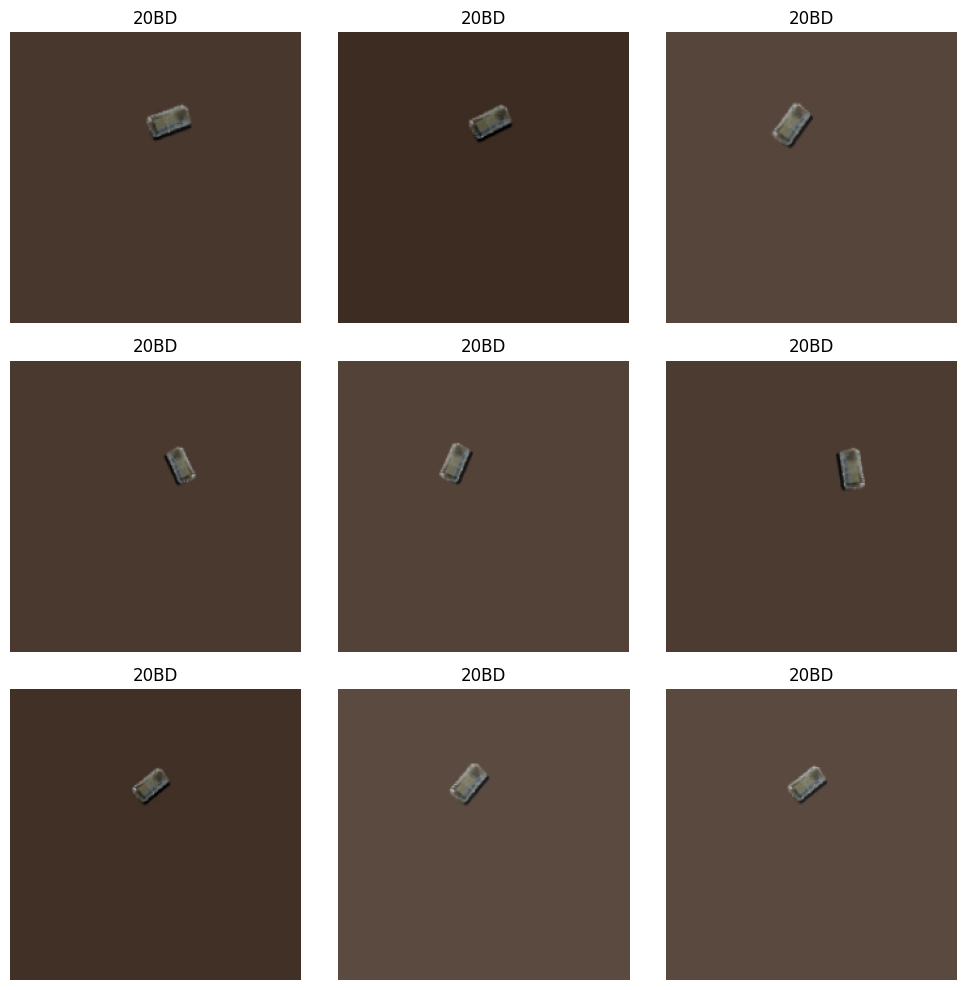

In [64]:
for images, labels in train_ds.take(1):

    sample_image = images[0]
    sample_label = int(labels[0].numpy())

    plt.figure(figsize=(10, 10))

    for i in range(9):

        augmented_image = data_augmentation(
            tf.expand_dims(sample_image,axis=0),training=True)

        plt.subplot(3,3,i + 1)

        plt.imshow(augmented_image[0].numpy().astype("uint8"))

        plt.title(class_names[sample_label])

        plt.axis("off")

    plt.tight_layout()
    plt.show()

## 11. Prefetch for Performance

In [65]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

## 12. Build CNN Model (Functional API)

In [66]:
inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = data_augmentation(inputs)

x = Rescaling(1.0 / 255)(x)

x = Conv2D(filters=32,kernel_size=3)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling2D()(x)

x = Conv2D(filters=64,kernel_size=3)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling2D()(x)

x = Conv2D(filters=128,kernel_size=3)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling2D()(x)

x = GlobalAveragePooling2D()(x)

x = Dense(128,activation="relu")(x)
x = Dropout(0.4)(x)

outputs = Dense(num_classes,activation="softmax")(x)

model = Model(inputs=inputs,outputs=outputs)

In [67]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,301 (434.77 KB)

 Trainable params: 110,853 (433.02 KB)

 Non-trainable params: 448 (1.75 KB)

## 13. Compile Model

In [68]:
model.compile(optimizer=Adam(learning_rate=1e-4),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

## 14. Callbacks & Class Weights

In [69]:
es = EarlyStopping(monitor="val_accuracy",mode="max",patience=8,min_delta=0.01,restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor="val_accuracy",mode="max",factor=0.5,patience=3,min_lr=1e-6,verbose=1)

In [70]:
unique_classes = np.unique(train_labels)

weights = compute_class_weight(class_weight="balanced",classes=unique_classes,y=train_labels)

class_weights = {int(class_index): float(weight)for class_index, weight in zip(unique_classes,weights)}

print("Class weights:")
print(class_weights)

Class weights:
{0: 0.9810055865921787, 1: 1.0707317073170732, 2: 0.9648351648351648, 3: 1.0578313253012048, 4: 0.9390374331550803}


## 15. Train Model

In [71]:
history = model.fit(train_ds,validation_data=val_ds,epochs=40,callbacks=[es, reduce_lr],class_weight=class_weights)

Epoch 1/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 29s 963ms/step - accuracy: 0.2130 - loss: 1.7726 - val_accuracy: 0.2740 - val_loss: 1.5975 - learning_rate: 1.0000e-04
Epoch 2/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 26s 946ms/step - accuracy: 0.2551 - loss: 1.6325 - val_accuracy: 0.0137 - val_loss: 1.5833 - learning_rate: 1.0000e-04
Epoch 3/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 40s 902ms/step - accuracy: 0.2756 - loss: 1.5795 - val_accuracy: 0.0137 - val_loss: 1.5980 - learning_rate: 1.0000e-04
Epoch 4/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.3172 - loss: 1.5611
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
28/28 ━━━━━━━━━━━━━━━━━━━━ 25s 904ms/step - accuracy: 0.3326 - loss: 1.5367 - val_accuracy: 0.0091 - val_loss: 1.6412 - learning_rate: 1.0000e-04
Epoch 5/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 25s 918ms/step - accuracy: 0.3417 - loss: 1.5215 - val_accuracy: 0.0091 - val_loss: 1.6728 - learning_rate: 5.0000e-05
Epoch 6/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 26s 935ms/step - accuracy:

## 16. Training Curves

In [92]:
history_df = pd.DataFrame(history.history)

history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.212984,1.772557,0.273973,1.597490,0.000100
1,0.255125,1.632492,0.013699,1.583307,0.000100
2,0.275626,1.579549,0.013699,1.597958,0.000100
3,0.332574,1.536740,0.009132,1.641187,0.000100
4,0.341686,1.521540,0.009132,1.672849,0.000050
5,0.362187,1.489017,0.009132,1.728080,0.000050
6,0.354214,1.474330,0.013699,1.761778,0.000050
7,0.382688,1.454195,0.022831,1.752244,0.000025
8,0.404328,1.438513,0.050228,1.733063,0.000025


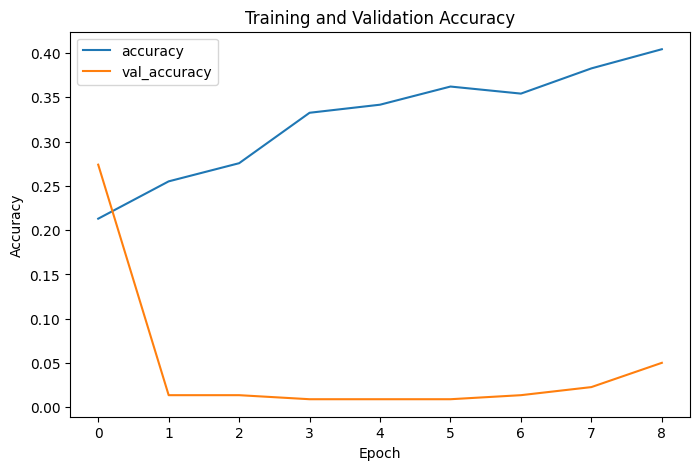

In [93]:
history_df[["accuracy", "val_accuracy"]].plot(figsize=(8, 5))

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

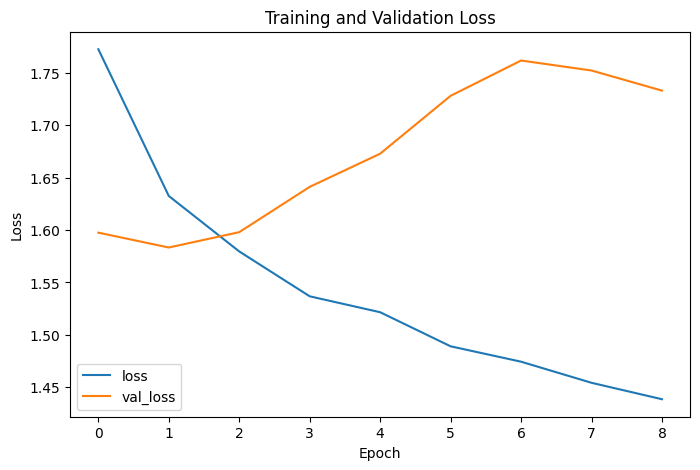

In [94]:
history_df[["loss", "val_loss"]].plot(figsize=(8, 5))

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 17. Evaluate on Validation Set

In [95]:
y_true = np.concatenate([labels.numpy()for _, labels in val_ds])

print("True labels:")
print(y_true)

print("Number of validation images:")
print(len(y_true))

True labels:
[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
Number of validation images:
219


In [96]:
y_pred_probabilities = model.predict(val_ds)

y_pred = np.argmax(y_pred_probabilities,axis=1)

print("Predicted labels:")
print(y_pred)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 800ms/step
Predicted labels:
[1 1 2 2 4 1 1 2 0 1 2 4 2 0 4 2 3 4 2 0 1 1 1 4 2 4 1 1 4 4 0 1 1 1 1 1 1
 4 4 4 2 4 1 1 1 4 4 4 1 4 2 1 1 0 1 2 1 1 1 1 1 1 1 0 2 1 4 4 1 1 4 2 2 4
 2 1 4 0 2 1 1 2 1 4 0 4 2 2 2 4 4 4 0 4 0 1 1 2 0 4 2 1 4 2 4 4 0 3 1 1 1
 2 1 1 4 0 2 1 1 1 1 4 1 4 0 1 1 4 2 1 1 1 4 1 4 0 2 1 4 4 0 4 2 4 2 1 0 4
 4 1 1 1 1 4 1 1 1 4 0 4 4 1 4 1 1 1 4 1 4 2 0 4 0 4 1 0 2 1 4 4 1 4 4 1 2
 1 2 1 2 1 1 1 1 1 1 4 2 1 1 2 1 1 4 1 1 1 1 2 2 4 1 1 1 2 4 1 1 1 1]


In [97]:
for class_name, probability in zip(class_names,y_pred_probabilities[0]):

    print(class_name,":",round(float(probability), 4))

10BD : 0.1968
1BD : 0.2028
20BD : 0.1985
500 Fils : 0.2012
5BD : 0.2008


In [98]:
accuracy = accuracy_score(y_true,y_pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.273972602739726


In [79]:
validation_loss, validation_accuracy = model.evaluate(val_ds)

print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 640ms/step - accuracy: 0.2740 - loss: 1.5975
Validation Loss: 1.5974901914596558
Validation Accuracy: 0.27397260069847107


## 18. Classification Report & Confusion Matrix

In [80]:
all_labels = list(range(num_classes))

report = classification_report(y_true,y_pred,labels=all_labels,target_names=class_names,zero_division=0)

print(report)

              precision    recall  f1-score   support

        10BD       0.00      0.00      0.00         0
         1BD       0.00      0.00      0.00         0
        20BD       0.00      0.00      0.00         0
    500 Fils       0.00      0.00      0.00         0
         5BD       1.00      0.27      0.43       219

    accuracy                           0.27       219
   macro avg       0.20      0.05      0.09       219
weighted avg       1.00      0.27      0.43       219



In [81]:
conf_matrix = confusion_matrix(y_true,y_pred,labels=all_labels)

print(conf_matrix)

[[ 0  0  0  0  0]
 [ 0  0  0  0  0]
 [ 0  0  0  0  0]
 [ 0  0  0  0  0]
 [21 97 39  2 60]]


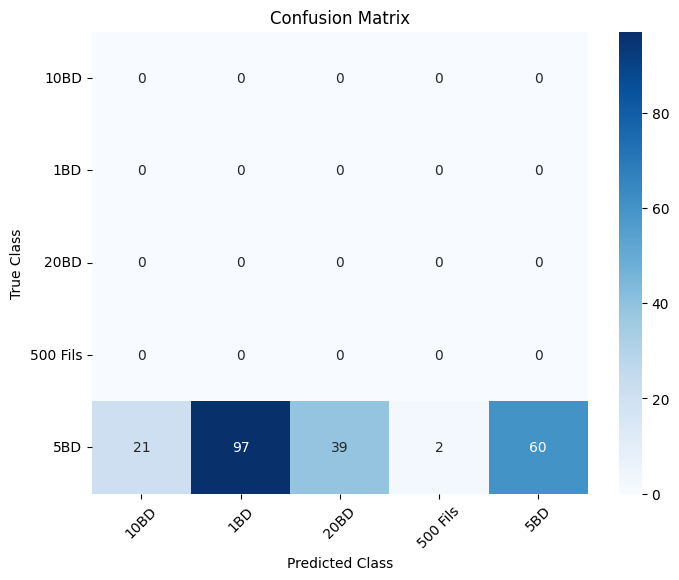

In [82]:
plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix,annot=True,cmap="Blues",fmt="g",xticklabels=class_names,yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

## 19. Error Analysis (Misclassified Images)

In [83]:
val_images = np.stack([image.numpy()for image, _ in val_ds.unbatch()])

print("Validation images shape:")
print(val_images.shape)

Validation images shape:
(219, 224, 224, 3)


In [99]:
wrong_indices = np.where(y_true != y_pred)[0]

print(len(wrong_indices),"misclassified images out of",len(y_true))

159 misclassified images out of 219


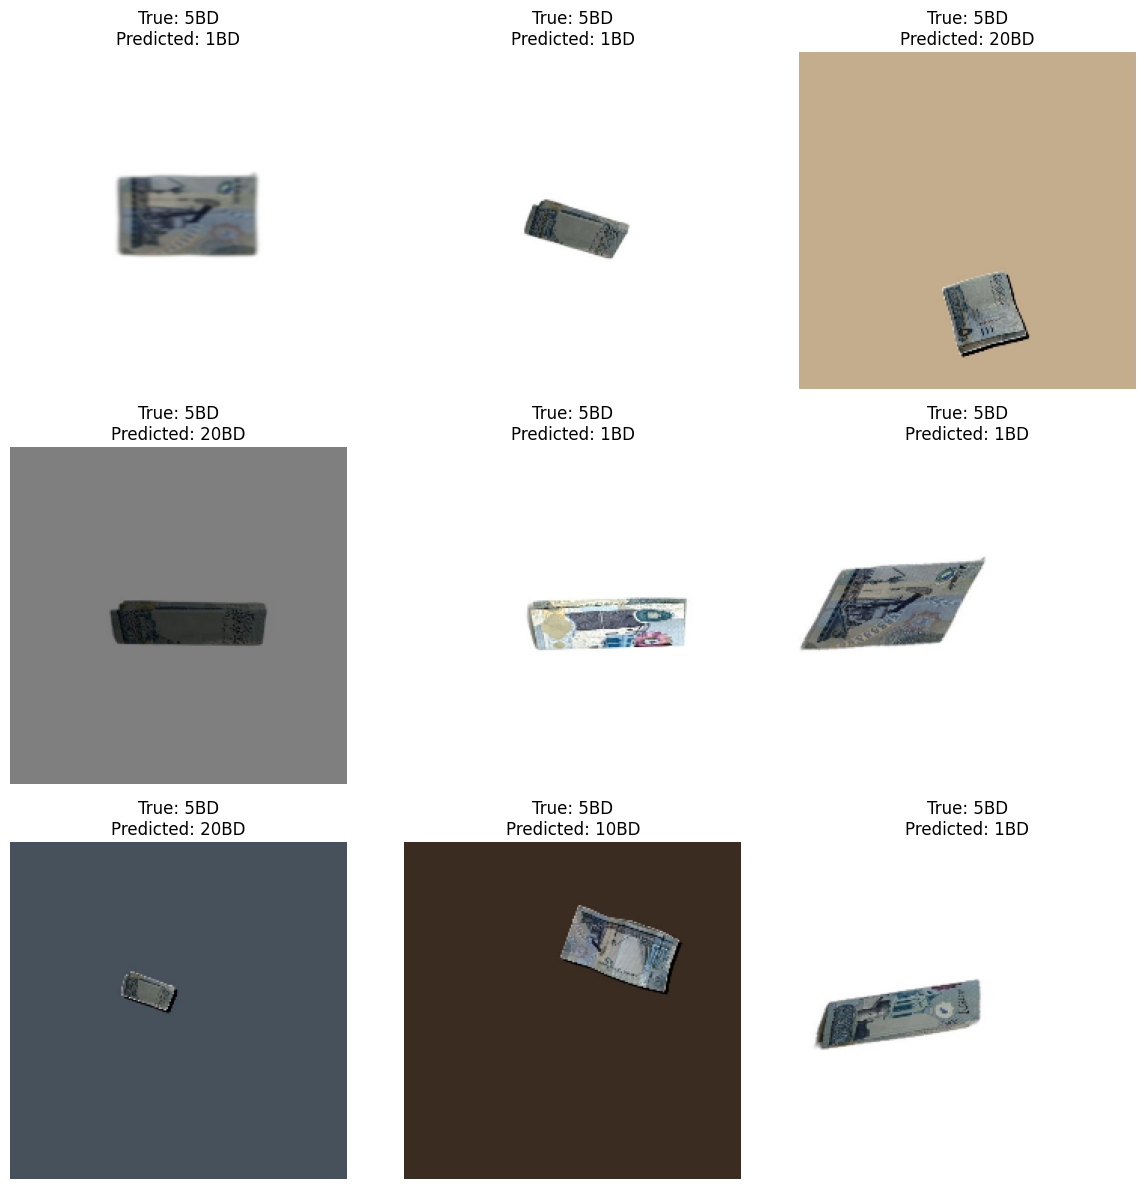

In [100]:
number_to_show = min(9,len(wrong_indices))

if number_to_show == 0:

    print("No misclassified images.")

else:

    plt.figure(figsize=(12, 12))

    for i in range(number_to_show):

        image_index = wrong_indices[i]

        plt.subplot(3,3,i + 1)

        plt.imshow(val_images[image_index].astype("uint8"))

        true_class = class_names[y_true[image_index]]

        predicted_class = class_names[y_pred[image_index]]

        plt.title(f"True: {true_class}\n"f"Predicted: {predicted_class}")

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [101]:
error_table = pd.DataFrame({"True Class": [class_names[y_true[index]] for index in wrong_indices],"Predicted Class": [
        class_names[y_pred[index]]for index in wrong_indices],"Confidence": [y_pred_probabilities[index][y_pred[index]]for index in wrong_indices]})

error_table

,True Class,Predicted Class,Confidence
0,5BD,1BD,0.202795
1,5BD,1BD,0.203286
2,5BD,20BD,0.205753
3,5BD,20BD,0.209803
4,5BD,1BD,0.203530
...,...,...,...
154,5BD,20BD,0.209853
155,5BD,1BD,0.203048
156,5BD,1BD,0.202269
157,5BD,1BD,0.202793


In [102]:
confusion_without_diagonal = conf_matrix.copy()

np.fill_diagonal(confusion_without_diagonal,0)

if confusion_without_diagonal.max() == 0:

    print("No confusion between classes.")

else:

    true_index, predicted_index = np.unravel_index(np.argmax(confusion_without_diagonal),confusion_without_diagonal.shape)

    print("Most common confusion:")

    print("True class:",class_names[true_index])

    print("Predicted as:",class_names[predicted_index])

    print("Number of mistakes:",confusion_without_diagonal[true_index,predicted_index])

Most common confusion:
True class: 5BD
Predicted as: 1BD
Number of mistakes: 97


## 20. Save Model & Class Names

In [103]:
# Save without optimizer state -> much smaller file, same accuracy
model.save("bahraini_currency_model.keras", include_optimizer=False)

import os
size_mb = os.path.getsize("bahraini_currency_model.keras") / (1024 * 1024)
print(f"Keras model size: {size_mb:.2f} MB")

Keras model size: 1.36 MB


### Optional: Export a much smaller TFLite version (recommended if still over 25MB)

In [104]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # dynamic range quantization

tflite_model = converter.convert()

with open("bahraini_currency_model.tflite", "wb") as f:
    f.write(tflite_model)

tflite_size_mb = os.path.getsize("bahraini_currency_model.tflite") / (1024 * 1024)
print(f"TFLite model size: {tflite_size_mb:.2f} MB")

Saved artifact at '/tmp/tmprixrp7pe'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_32')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132975560957520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132975560954640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132975560963088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132975560959824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132975560964048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132975560958672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132975560964240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132974880067792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132974880063568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132974880068368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13297488006

In [105]:
with open("class_names.json","w") as file:

    json.dump(class_names,file,indent=4)

## 21. Inference on a New Image

In [106]:
def predict_currency(image_path):

    image = tf.keras.utils.load_img(image_path,target_size=IMG_SIZE)

    image_array = tf.keras.utils.img_to_array(image)

    image_array = np.expand_dims(image_array,axis=0)

    probabilities = model.predict(image_array,verbose=0)[0]

    predicted_index = int(np.argmax(probabilities))

    predicted_class = class_names[predicted_index]

    confidence = float(probabilities[predicted_index])

    plt.figure(figsize=(6, 6))

    plt.imshow(image)

    plt.title(f"Prediction: {predicted_class} BHD\n"f"Confidence: {confidence:.2%}")

    plt.axis("off")
    plt.show()

    return predicted_class, confidence

## Final Reflection

1. Why did classification work well initially?

2. Which currency class had the highest precision?

3. Which currency class had the lowest recall?

4. Which currency classes were confused with each other?

5. Did lighting, angle or background affect the predictions?

6. What problems could object detection solve?

7. Which approach is more suitable for real-world deployment?

8. How could the system be improved further?